### Notebook 1:  Clustering con K-means
En este notebook vamos a implementar el algoritmo de clustering K-means en R. El objetivo es entender como funciona este algoritmo y  aprender a utilizarlo con un ejemplo simple. Se incluye además la estrategia para definir el número de grupos k. Al final se propone un ejercicio con nuevos datos, con el fin de aprender a utilizar el algoritmo. 

Para ello vamos a utilizar un conjunto de datos provenientes de un estudio de granos pertenecientes a distintas variedades de trigo. Los atributos de los datos provienen de una visualización de alta calidad de la estructura interna del grano utilizando una técnica de rayos X suaves. La ventaja de esta técnica es que no es destructiva y es considerablemente más económica que otras técnicas de imagen más sofisticadas como la microscopía de barrido o la tecnología láser. Las imágenes se registraron en placas KODAK de rayos X de 13x18 cm. Los estudios se llevaron a cabo utilizando grano de trigo cosechado en combinación procedente de campos experimentales, explorados en el Instituto de Agrofísica de la Academia de Ciencias de Polonia en Lublin.


Los atributos observados son seis parámetros geométricos medidos en los granos de trigo:

V1: área A

V2: perímetro P

V3: longitud de la semilla

V4: ancho de la semilla

V5: coeficiente de asimetría

V6: longitud de la ranura de la semilla

Se trata de analizar de que manera estos atributos permiten generar grupos en los datos que correspondan idealmente a cada variedad de trigo disponible en los datos.

In [1]:
# install.packages('ggplotify')
library(cluster)
library(ggplot2)
library(factoextra)
library(patchwork)
library(gridExtra)
library(ggplotify)

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



In [2]:
# Para hacer los graficos mas grandes
options(repr.plot.width = 25, repr.plot.height = 8) 

### **Ejercicio 1:**

1) De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.
2) Realice nuevamente los cálculos con el K óptimo y caracterice los grupos obtenidos. Interprete sus resultados

       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6       
 Min.   :0.765   Min.   :4.519  
 1st Qu.:2.562   1st Qu.:5.045  
 Median :3.599   Median :5.223  
 Mean   :3.700   Mean   :5.408  
 3rd Qu.:4.769   3rd Qu.:5.877  
 Max.   :8.456   Max.   :6.550  

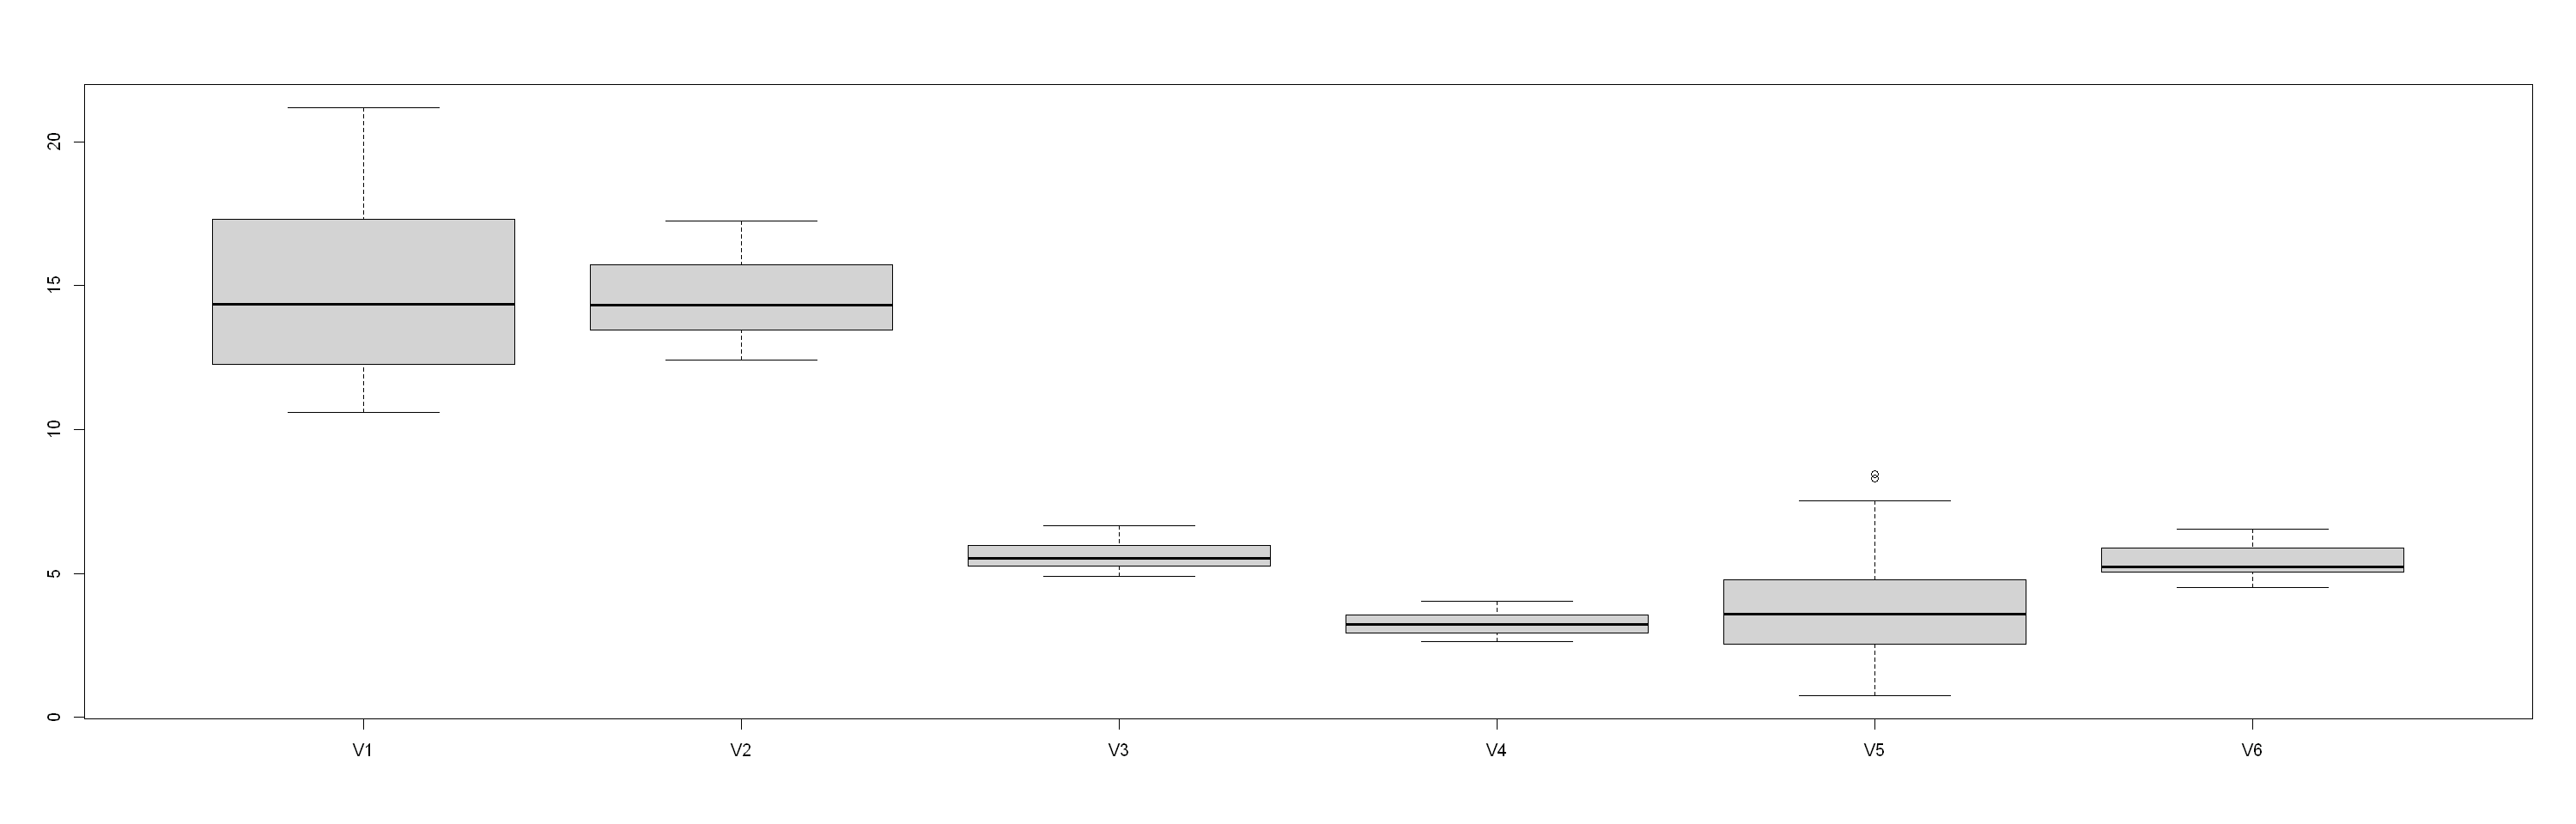

In [3]:
datos <-read.table("..//data//semillas1.txt",dec=".")
summary(datos)
boxplot(datos)

Call:
princomp(x = datos, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


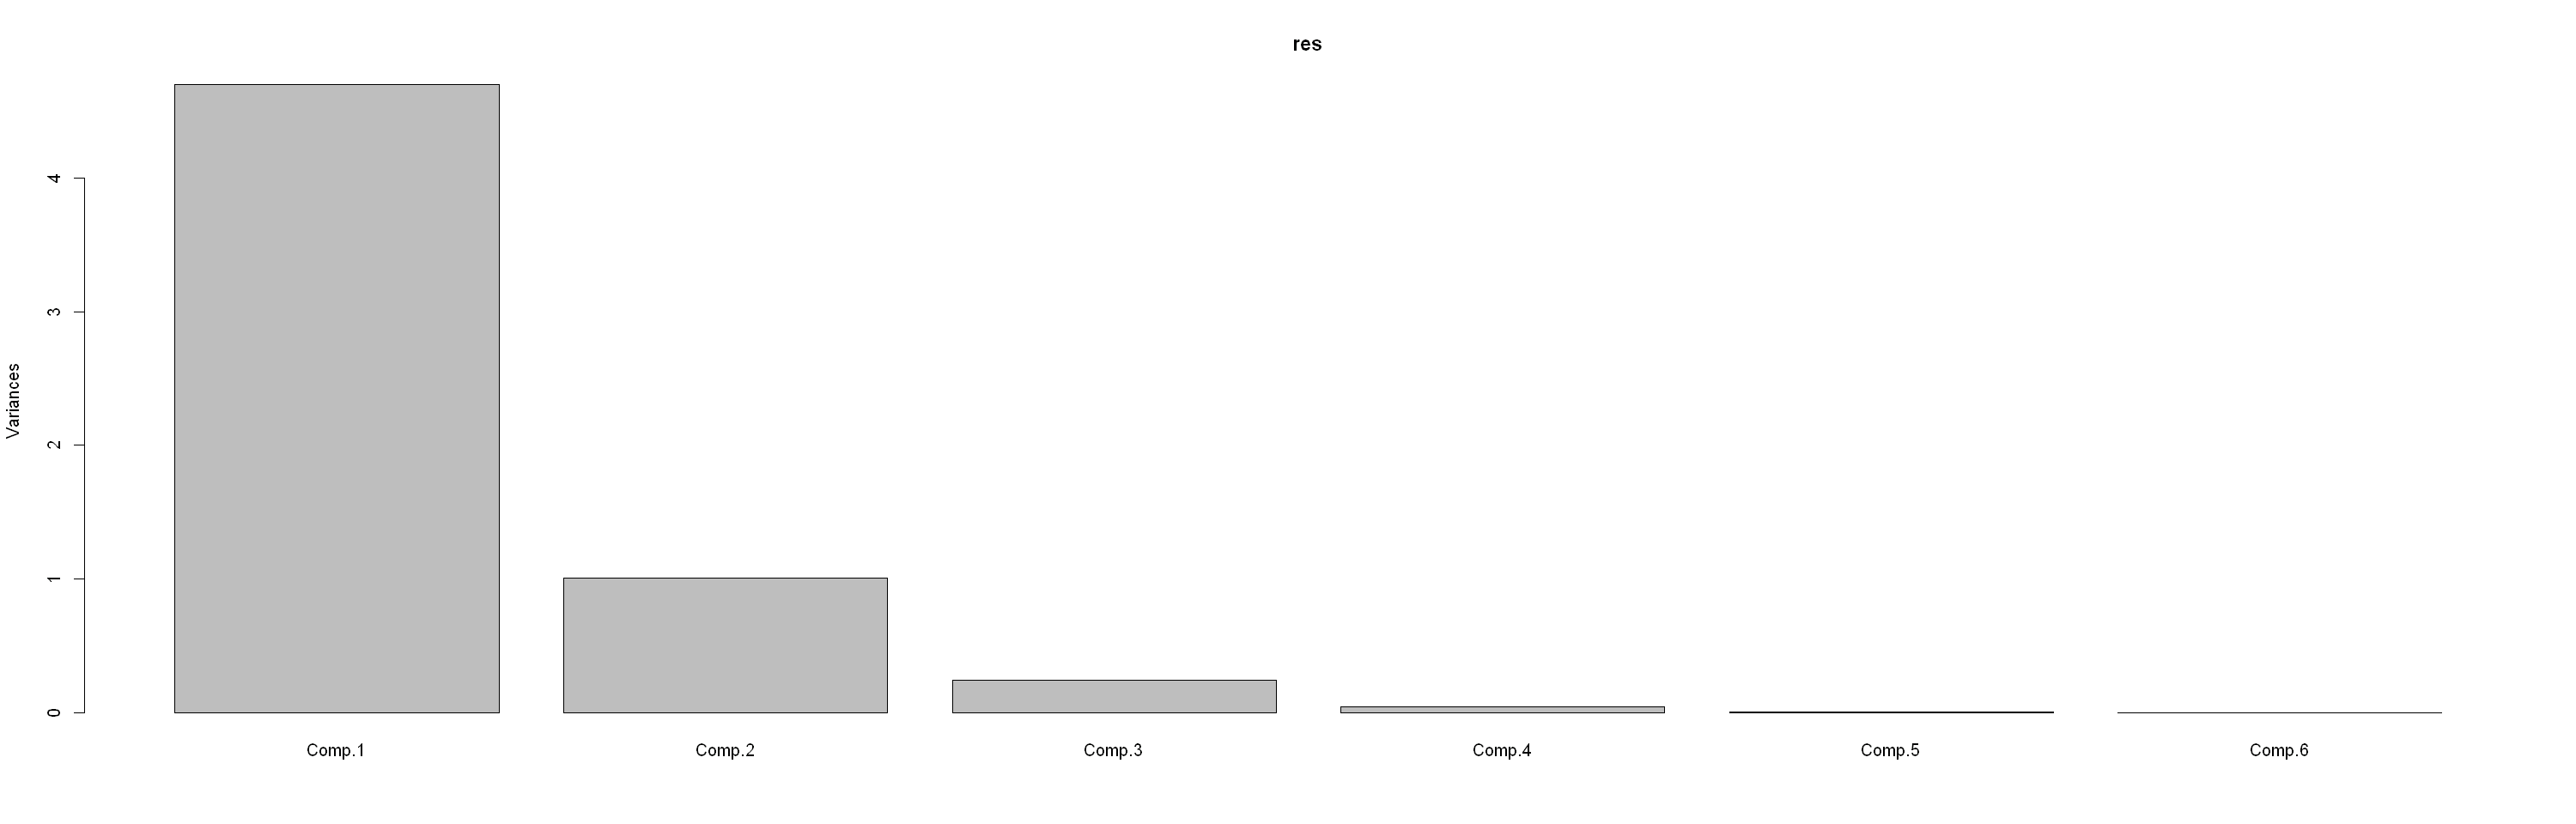

In [4]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos, cor=TRUE)
print(res)
plot(res)

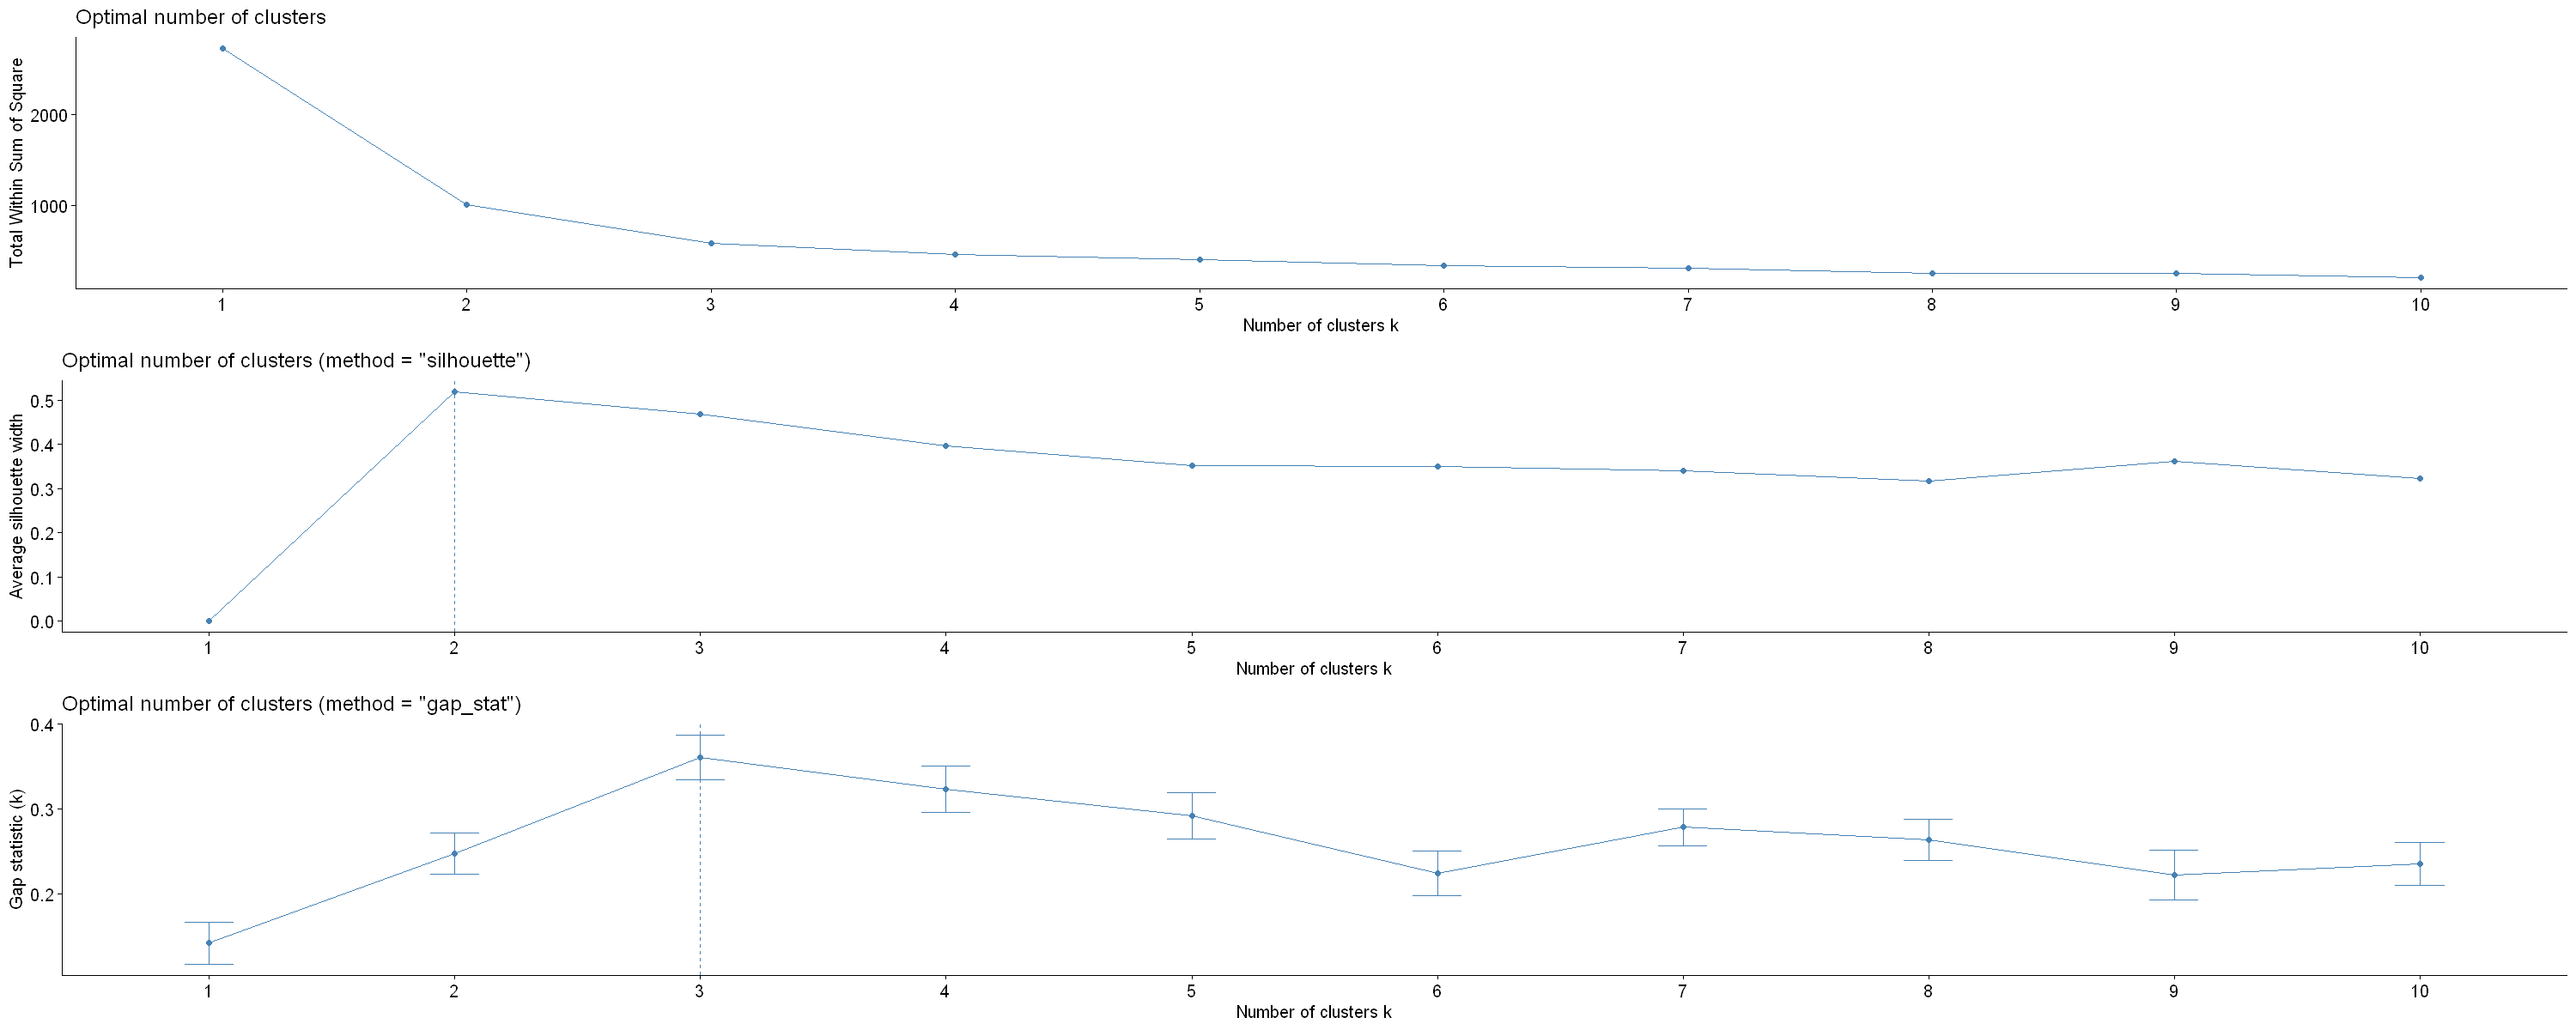

In [5]:
## Graficos de seleccion de K

### El "Codo" en formato ggplot
g1 <- fviz_nbclust(datos, kmeans, method = "wss")

### Análisis de Silueta (Busca el máximo)
g2 <- fviz_nbclust(datos, kmeans, method = "silhouette")

### Estadística Gap (Busca la mayor desviación del azar)
g3 <- fviz_nbclust(datos, kmeans, method = "gap_stat")

# # Por si se quiere algo mas experimentable
# gap_stat <- clusGap(df,
#     FUN = kmeans,
#     nstart = 25,
#     K.max = 10,
#     B = 50
# )

options(repr.plot.height = 10) 
# fviz_gap_stat(gap_stat)
grid.arrange(g1, g2, g3, ncol = 1)
options(repr.plot.height = 8) 

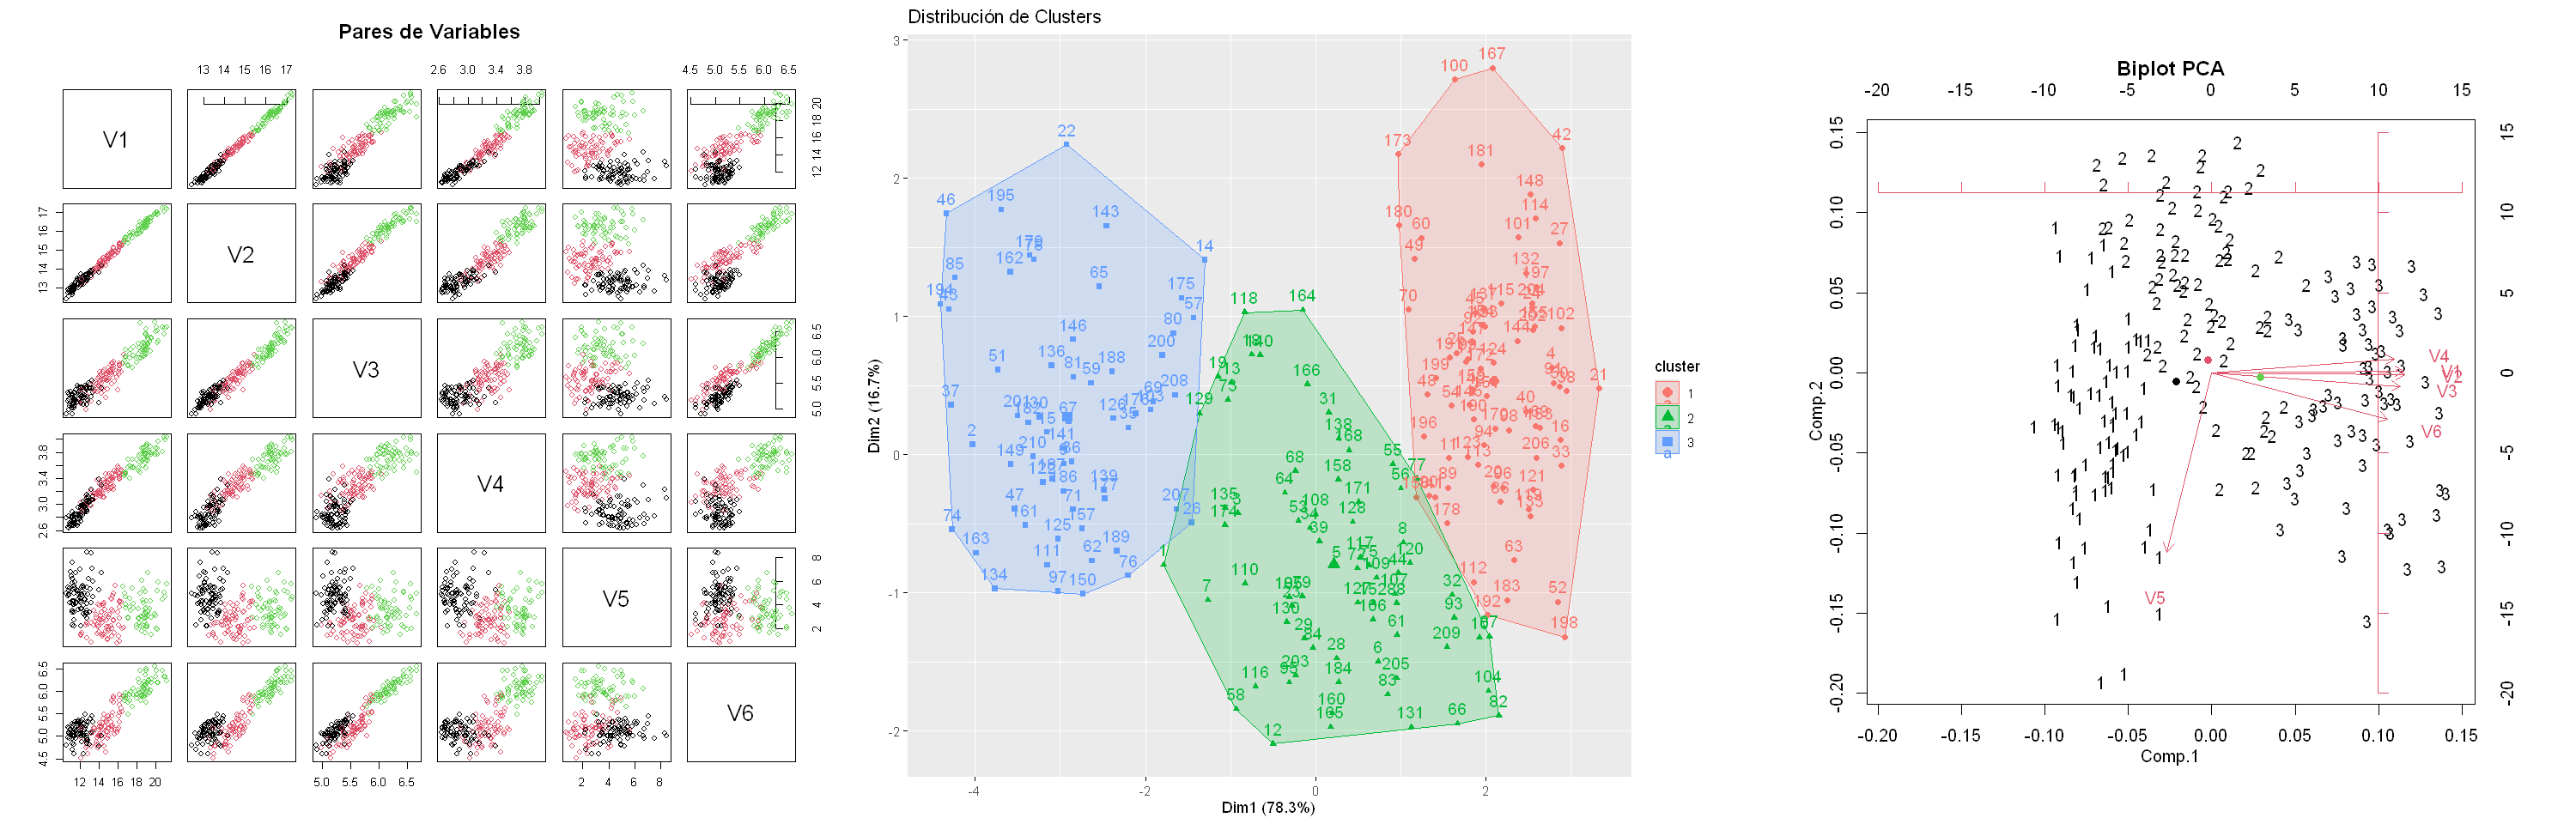

In [6]:
## Visualizacion de k
k0=3
cl<-kmeans(datos,k0,iter.max=1000,nstart=10)

res <- princomp(datos, cor=TRUE)
res2 <- predict(res, cl$centers)

# 1.
p1 <- as.grob(~pairs(datos, col=cl$cluster, main="Pares de Variables"))

# 2. 
p2 <- fviz_cluster(cl, datos, main = "Distribución de Clusters")

# 3.
p3 <- as.grob(~{
  biplot(res, xlabs=cl$cluster, main="Biplot PCA")
  points(res2[,1:2], col=1:k0, pch=19)
})

grid.arrange(p1, p2, p3, ncol = 3)

#### **Respuestas**

1. De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.
   
    Tras analizar los tres criterios de selección, se determina que **$K=3$** es el valor más adecuado para este conjunto de datos. 
    El Método del Codo (WSS) muestra una disminución drástica de la inercia hasta el valor de 3, punto a partir del cual la ganancia de información se vuelve marginal. Aunque el Análisis de Silueta sugiere un $K=2$, este tiende a ser un método conservador que prioriza la separación absoluta de las fronteras de los grupos, sin embargo, la Estadística Gap identifica un pico claro en K=3, indicando que existe una estructura de tres grupos con una varianza interna significativamente menor a la de una distribución aleatoria. 
    Finalmente, la elección de $K=3$ tiene una sólida justificación en los datos, ya que el conjunto de datos representa tres variedades reales de trigo (Kama, Rosa y Canadian), lo que permite que el modelo recupere la estructura natural de los datos.

2. Realice nuevamente los cálculos con el K óptimo y caracterice los grupos obtenidos. Interprete sus resultados
    
    Al ejecutar el algoritmo con el valor óptimo de **K=3**, se obtiene una segmentación clara y coherente. Visualizando los resultados en el plano de los Componentes Principales (PCA) y analizando los centroides de cada cluster, podemos caracterizar los grupos de la siguiente manera:

    1) **Grupo de Semillas Grandes (Rosa):** Presenta los valores más altos en área ($V1$) y perímetro ($V2$), lo que indica semillas morfológicamente más robustas.
    2) **Grupo de Semillas Estrechas/Pequeñas (Canadian):** Se caracteriza por dimensiones menores en casi todas las variables, pero con una relación de longitud/ancho específica.
    3) **Grupo de Semillas Asimétricas (Kama):** Presenta valores intermedios de volumen, pero destaca por un mayor coeficiente de asimetría ($V5$).

    En conclusión, las variables de **Área y Perímetro** son los descriptores que mejor discriminan entre los grupos, permitiendo una separación casi total de las nubes de puntos con muy poco solapamiento, lo que valida la efectividad del clustering para diferenciar variedades botánicas basadas únicamente en su geometría."

### **Ejercicio 2:**
Realice un análisis de clustering con el conjunto de datos correspondiente a su grupo, para el cual ya realizó un análisis exploratorio y de PCA (No olvide de excluir la penúltima y última columna de sus datos originales).

1. Describa los datos y discuta la pertinencia de realizar un análisis de clustering o agrupamiento
2. Utilice k-means para realizar el clustering de los datos y calcule el K óptimo. 
3. Caracterice los grupos obtenidos con el K óptimo. Interprete sus resultados


In [ ]:
datos_grupo <- read.csv("..//datasets_simulados//Grupo10.csv", dec=".", sep=";")

# Filtro Negativos
datos_grupo <- datos_grupo[datos_grupo$distancia > 0 & 
                           datos_grupo$tiempo > 0 & 
                           datos_grupo$viajes > 0, ]

# Agregamos velocidad promedio antes de filtrar
datos_grupo$velocidad <- datos_grupo$distancia / datos_grupo$tiempo

# Solo usamos los datos numericos (ahora incluye velocidad)
datos_grupo_numericos <- datos_grupo[ , c("viajes", "distancia", "tiempo", "velocidad")]
# Omitimos los valores nulos y inf
datos_grupo_numericos <- na.omit(datos_grupo_numericos)
datos_grupo_numericos <- datos_grupo_numericos[is.finite(datos_grupo_numericos$velocidad), ]

summary(datos_grupo)

boxplot(datos_grupo_numericos, main="Boxplot de Variables Numéricas")

ERROR: Error in datos_grupo[, c("viajes", "distancia", "tiempo", "velocidad")]: incorrect number of dimensions


In [ ]:
# Ver la magnitud del problema
summary(datos_grupo_numericos$tiempo)

# Filtrar outliers extremos con IQR
Q1 <- quantile(datos_grupo_numericos$tiempo, 0.25)
Q3 <- quantile(datos_grupo_numericos$tiempo, 0.75)
IQR_val <- Q3 - Q1

datos_grupo_numericos <- datos_grupo_numericos[
  datos_grupo_numericos$tiempo >= (Q1 - 3 * IQR_val) &
  datos_grupo_numericos$tiempo <= (Q3 + 3 * IQR_val), ]

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.18   30.95   46.57   49.55   62.21  253.86 

Call:
princomp(x = datos_grupo_numericos, cor = TRUE)

Standard deviations:
   Comp.1    Comp.2    Comp.3    Comp.4 
1.2299052 1.0546862 0.8638770 0.7928976 

 4  variables and  441 observations.


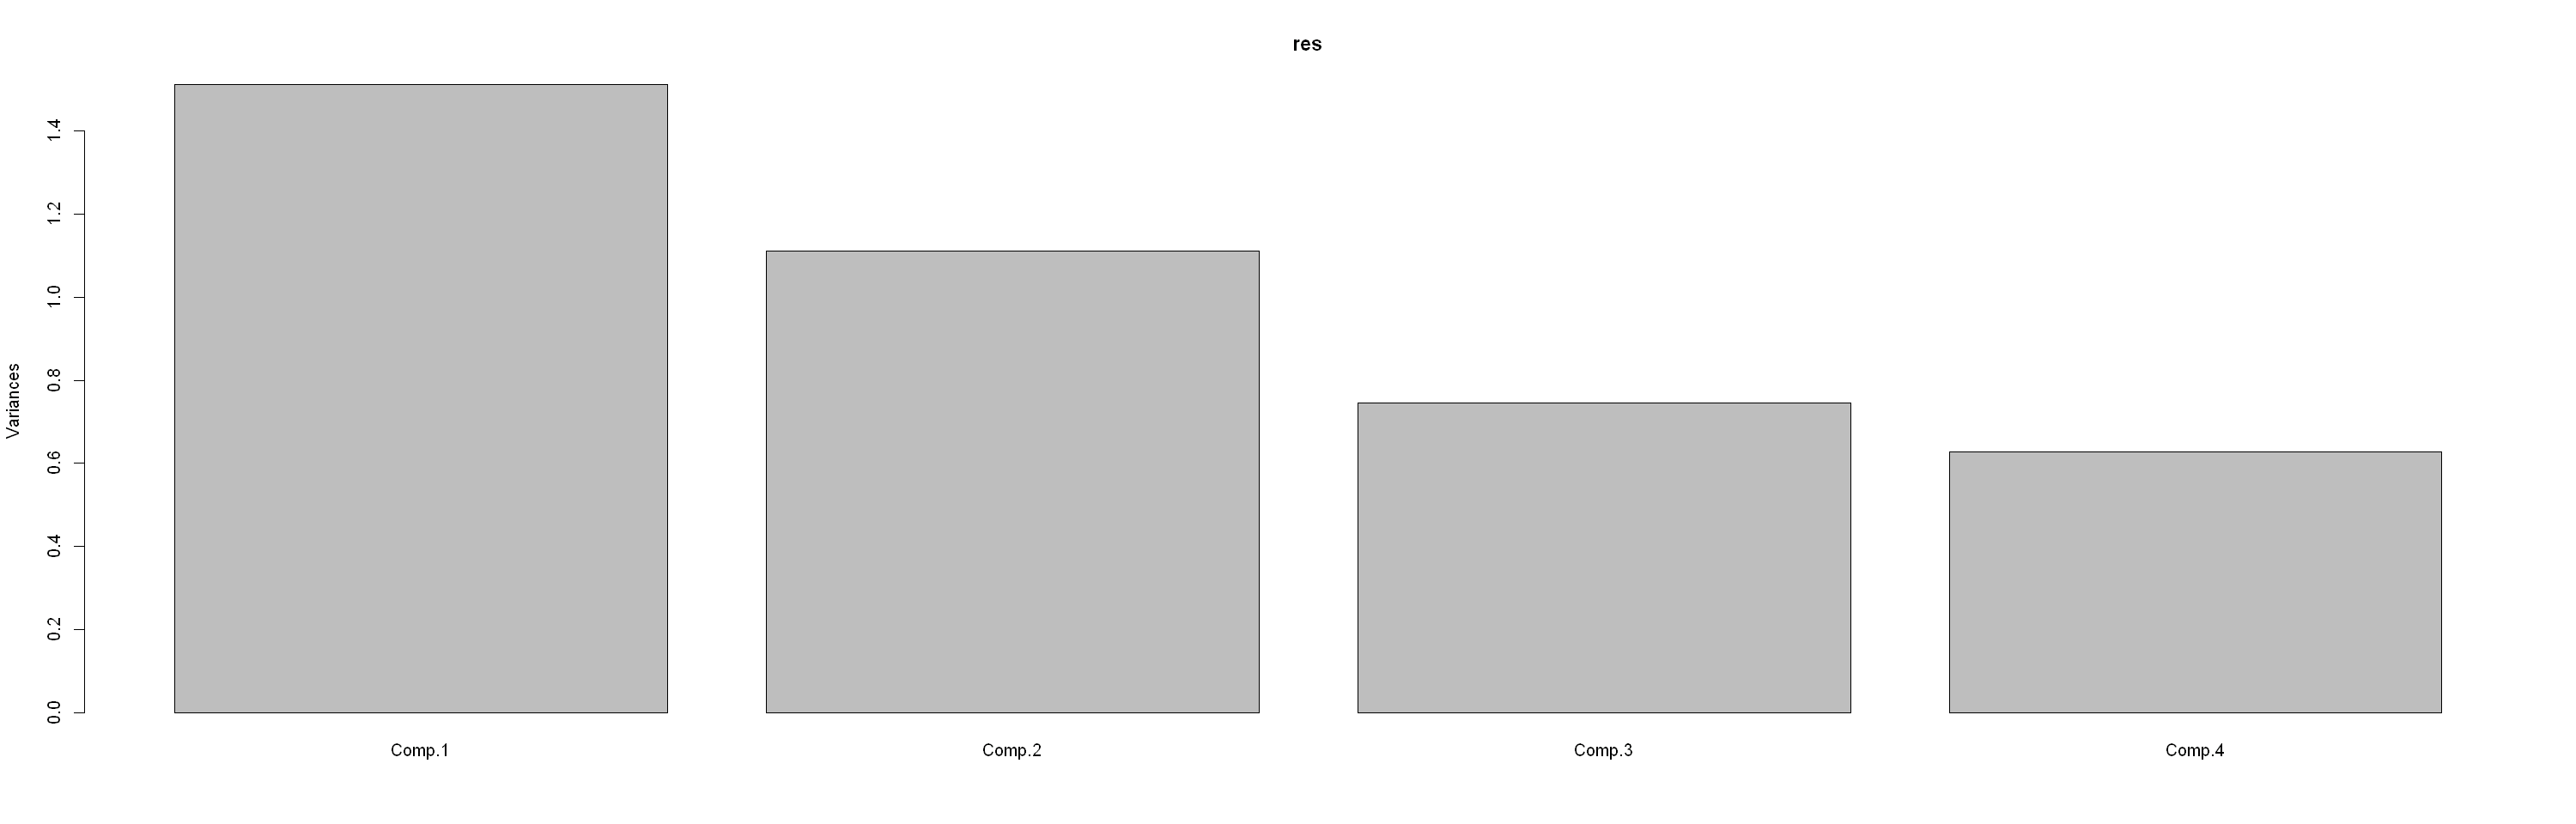

In [ ]:
res <- princomp(datos_grupo_numericos, cor=TRUE)
print(res)
plot(res) 

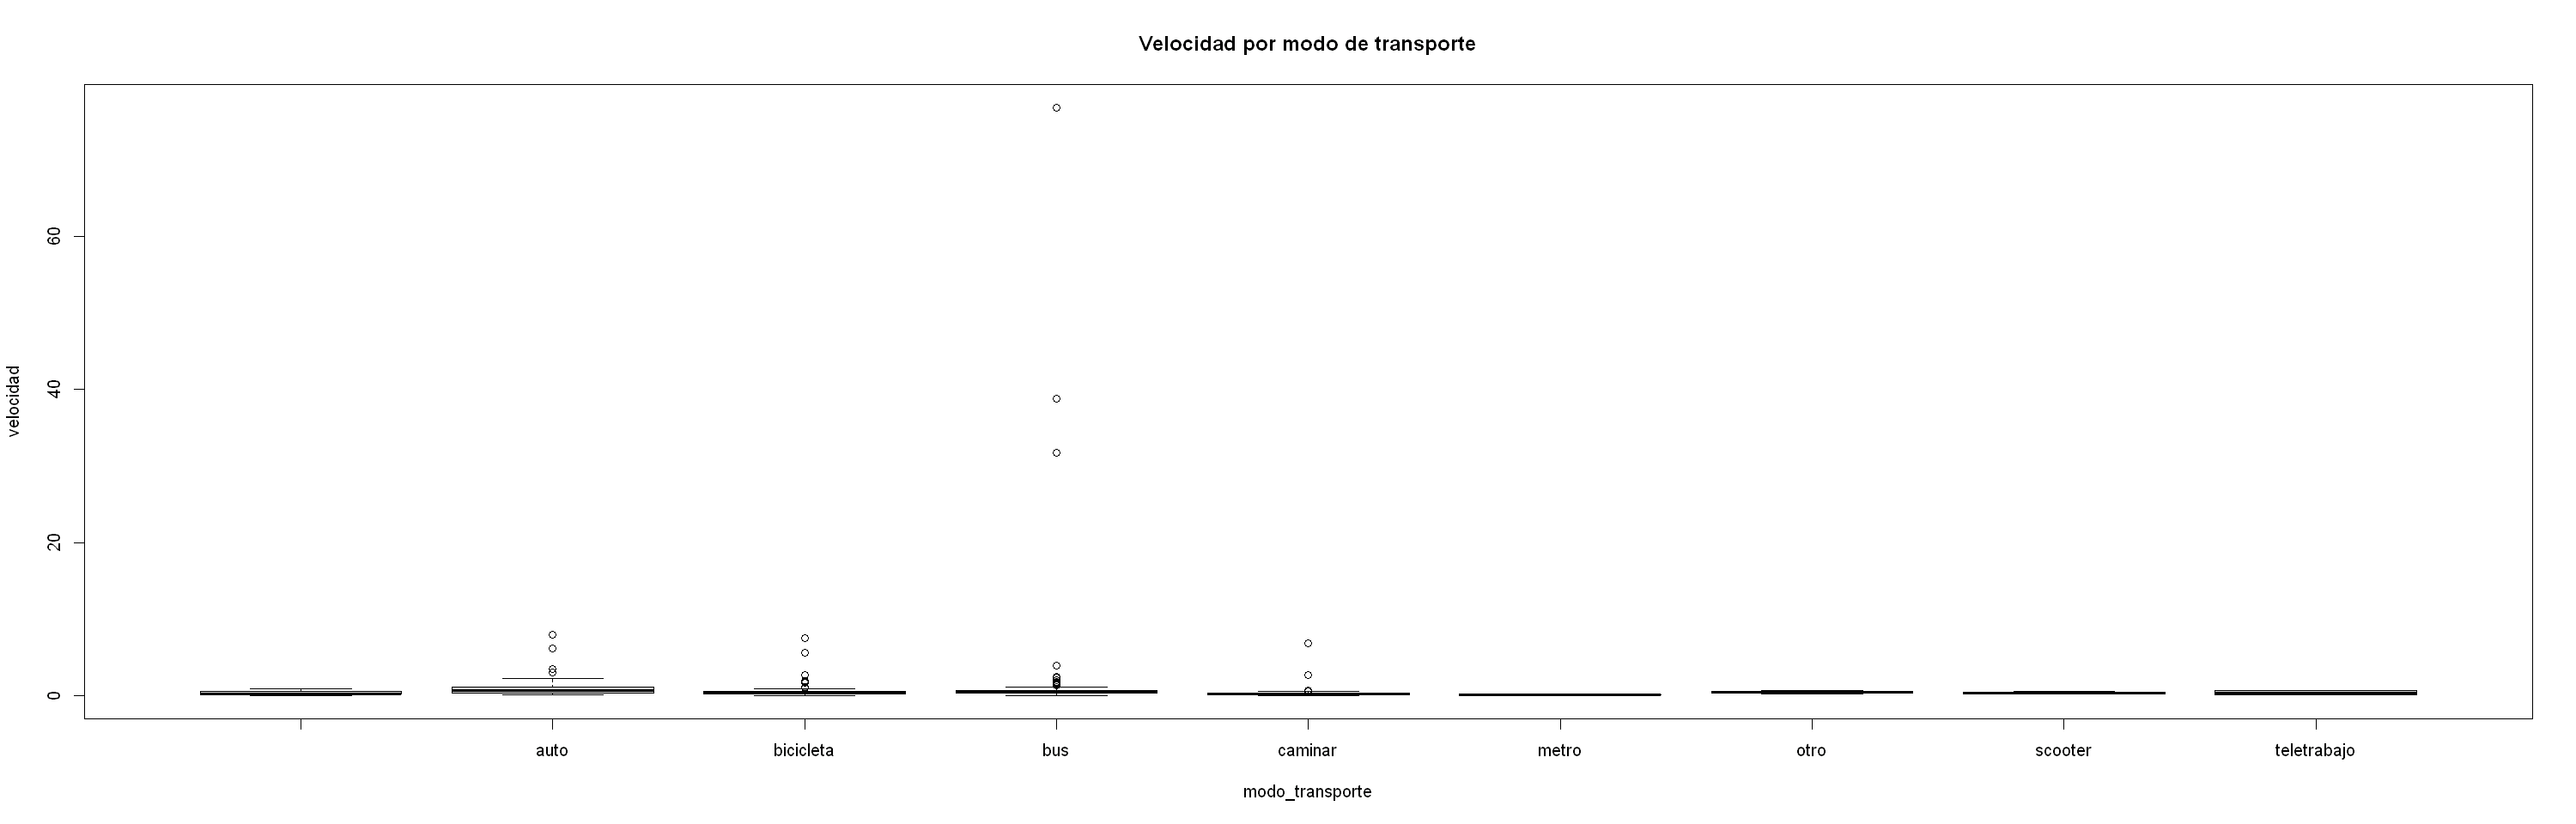

In [ ]:
boxplot(velocidad ~ modo_transporte, data=datos_grupo, 
        main="Velocidad por modo de transporte")

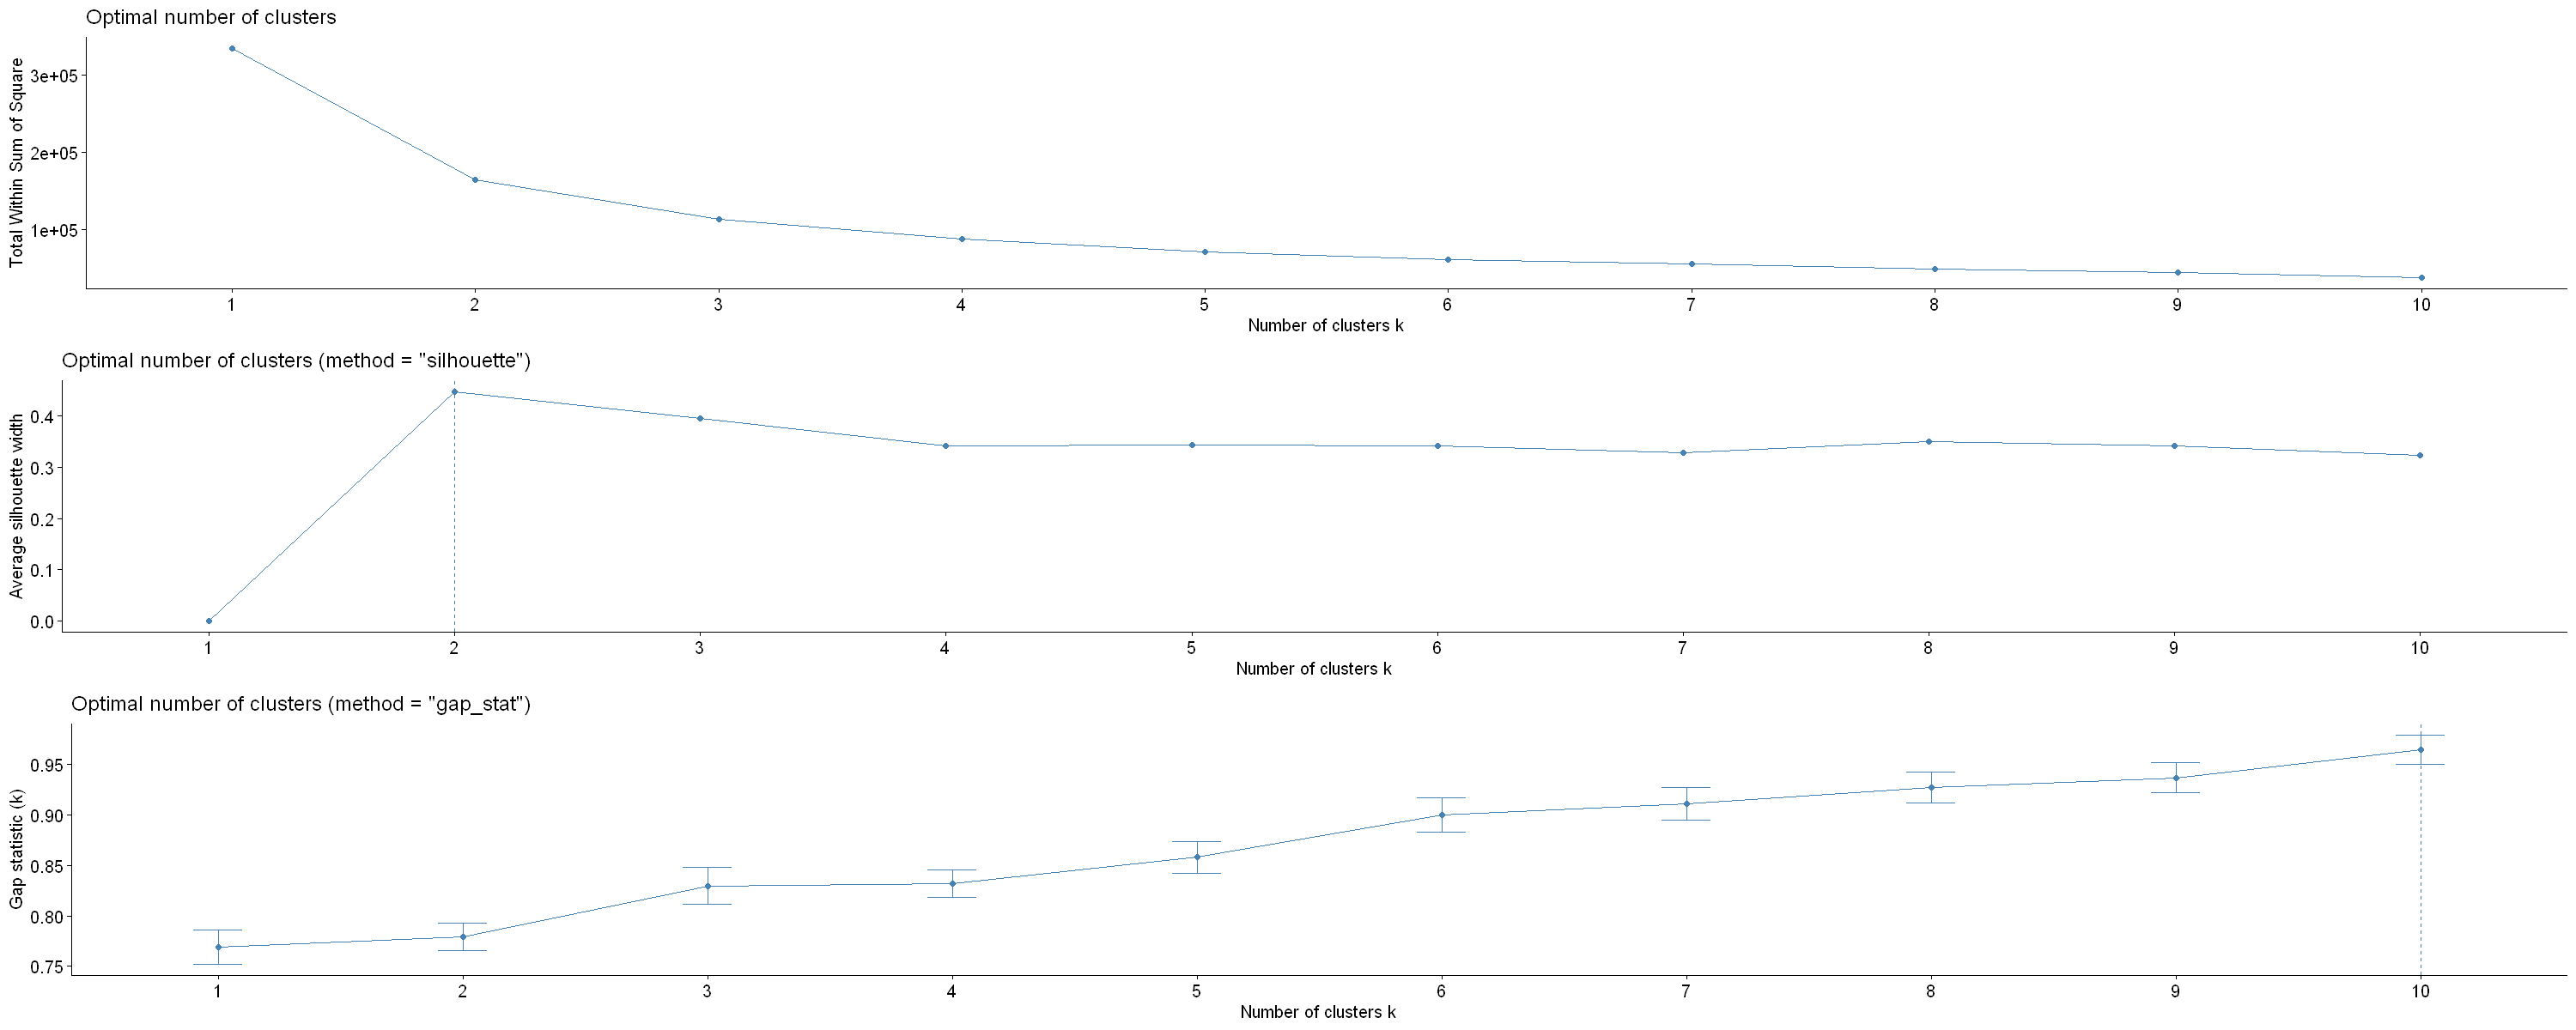

In [ ]:
## Graficos de seleccion de K

### El "Codo" en formato ggplot
g1 <- fviz_nbclust(datos_grupo_numericos, kmeans, method = "wss")

### Análisis de Silueta (Busca el máximo)
g2 <- fviz_nbclust(datos_grupo_numericos, kmeans, method = "silhouette")

### Estadística Gap (Busca la mayor desviación del azar)
g3 <- fviz_nbclust(datos_grupo_numericos, kmeans, method = "gap_stat")

# # Por si se quiere algo mas experimentable
# gap_stat <- clusGap(df,
#     FUN = kmeans,
#     nstart = 25,
#     K.max = 10,
#     B = 50
# )

options(repr.plot.height = 10) 
# fviz_gap_stat(gap_stat)
grid.arrange(g1, g2, g3, ncol = 1)
options(repr.plot.height = 8) 

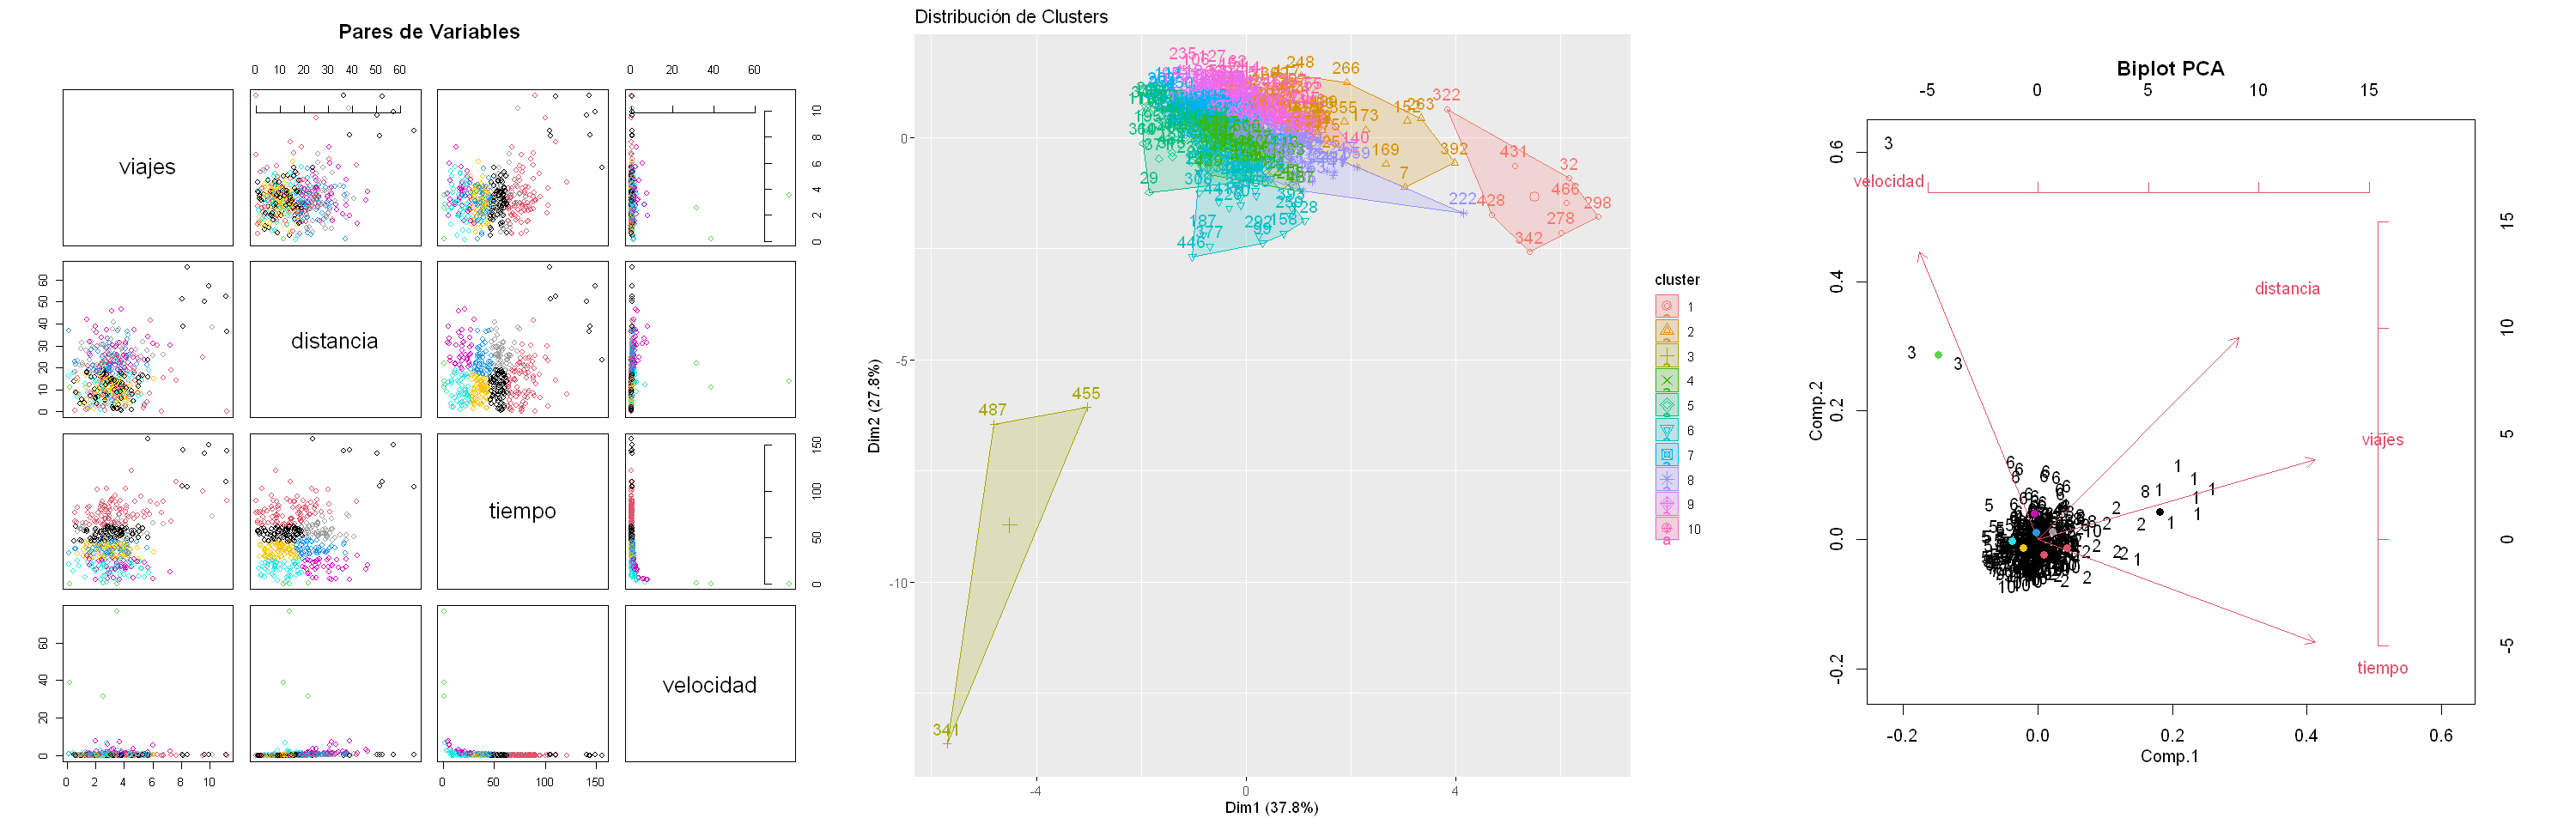

In [ ]:
## Visualizacion de k
k0=10
cl<-kmeans(datos_grupo_numericos,k0,iter.max=1000,nstart=10)

res <- princomp(datos_grupo_numericos, cor=TRUE)
res2 <- predict(res, cl$centers)

# 1.
p1 <- as.grob(~pairs(datos_grupo_numericos, col=cl$cluster, main="Pares de Variables"))

# 2. 
p2 <- fviz_cluster(cl, datos_grupo_numericos, main = "Distribución de Clusters")

# 3.
p3 <- as.grob(~{
  biplot(res, xlabs=cl$cluster, main="Biplot PCA")
  points(res2[,1:2], col=1:k0, pch=19)
})

grid.arrange(p1, p2, p3, ncol = 3)